<a href="https://colab.research.google.com/github/Zeeba1705/atml_PA0/blob/main/Copy_of_task1_pa0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#ATML PA0 - Task 1


Inner workings of Resnet-152

In [2]:
import torch
import torchvision

print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("CUDA available:", torch.cuda.is_available())

#delete after

PyTorch version: 2.11.0+cu128
Torchvision version: 0.26.0+cu128
CUDA available: True


In [3]:
import copy
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

import random
import time
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from torchvision.models import ResNet152_Weights, resnet152

In [4]:
#so that there's consistency between runs

SEED = 42
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


Preprocessing CIFAR-10: In order to match the input expected by Resnet-152


In [11]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [12]:
train_dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

100%|██████████| 170M/170M [33:24<00:00, 85.0kB/s]


In [13]:
train_size = 45000
val_size = 5000

train_subset, val_subset = random_split(
    train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

train_loader = DataLoader(
    train_subset,
    batch_size=64,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_subset,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

**Loading Resnet-152:**

In [5]:
weights = ResNet152_Weights.DEFAULT
model = resnet152(weights=weights)

Downloading: "https://download.pytorch.org/models/resnet152-f82ba261.pth" to /root/.cache/torch/hub/checkpoints/resnet152-f82ba261.pth


100%|██████████| 230M/230M [00:01<00:00, 178MB/s]


In [9]:
#final layer of Resnet-152
print(model.fc)

Linear(in_features=2048, out_features=1000, bias=True)


This is the final layer I need to replace, as currently the classifier produces scores for a 1000 classes (out_features=1000), whereas for CIFAR-10 we only need 10.

In [6]:
#freezing parameters first
for param in model.parameters():
    param.requires_grad = False

#now we replace the final layer, goign from 1000 to 10 as needed
model.fc = nn.Linear(2048, 10)
print(model.fc)

model = model.to(device)

criterion = nn.CrossEntropyLoss()

#Optimizer: we r only updating the new classification layer
optimizer = torch.optim.Adam(
    model.fc.parameters(),
    lr=0.001
)

Linear(in_features=2048, out_features=10, bias=True)


In [11]:
for name, param in model.named_parameters():
    if param.requires_grad:
        print(name)
  #just checking.. should get only fc.bias, fc.weight.

fc.weight
fc.bias


In [15]:
num_e= 3

for epoch in range(num_e):

    model.train()

    tr_loss= 0
    train_correct= 0
    train_total= 0

    for images, labels in train_loader:

        images= images.to(device)
        labels= labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss= criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        tr_loss+= loss.item() * images.size(0)

        predicted= outputs.argmax(dim=1)

        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    tr_loss= tr_loss / train_total
    train_accuracy= train_correct / train_total

    model.eval()

    val_loss= 0
    val_correct= 0
    val_total= 0

    with torch.no_grad():

        for images, labels in val_loader:

            images= images.to(device)
            labels= labels.to(device)

            outputs= model(images)

            loss= criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)

            predicted= outputs.argmax(dim=1)

            val_total+= labels.size(0)
            val_correct+= (predicted == labels).sum().item()

    val_loss= val_loss / val_total
    val_accuracy= val_correct / val_total


    print(
        f"Epoch {epoch + 1}/{num_e} | "
        f"Train Loss: {tr_loss:.4f} | "
        f"Train Accuracy: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Accuracy: {val_accuracy:.4f}"
    )

Epoch 1/3 | Train Loss: 0.7207 | Train Accuracy: 0.7800 | Val Loss: 0.5228 | Val Accuracy: 0.8242
Epoch 2/3 | Train Loss: 0.5000 | Train Accuracy: 0.8340 | Val Loss: 0.4734 | Val Accuracy: 0.8410
Epoch 3/3 | Train Loss: 0.4497 | Train Accuracy: 0.8492 | Val Loss: 0.4549 | Val Accuracy: 0.8438


##**1.2 Residual Connections in Practice**

In [7]:
print(model.layer1[1])

Bottleneck(
  (conv1): Conv2d(256, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
)


Revision note: Residual connections let each block learn a correction to its input rather than an entirely new representation, while also providing a direct pathway for information and gradients through very deep networks. Removing them should probably impact performance by quite a bit.

In [14]:
import types

def remove_da_skip(self, x):

    out = self.conv1(x)
    out = self.bn1(out)
    out = self.relu(out)

    out = self.conv2(out)
    out = self.bn2(out)
    out = self.relu(out)

    out = self.conv3(out)
    out = self.bn3(out)

    #skipped residual
    out = self.relu(out)

    return out

In [15]:
#choosing layer1[1], layer2[3], and layer3[6] to skip residual connection

model.layer1[1].forward = types.MethodType(remove_da_skip, model.layer1[1])

model.layer2[3].forward = types.MethodType(remove_da_skip, model.layer2[3])

model.layer3[6].forward = types.MethodType(remove_da_skip,model.layer3[6])

In [16]:
num_e= 3

for epoch in range(num_e):

    model.train()

    tr_loss= 0
    train_correct= 0
    train_total= 0

    for images, labels in train_loader:

        images= images.to(device)
        labels= labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss= criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        tr_loss+= loss.item() * images.size(0)

        predicted= outputs.argmax(dim=1)

        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    tr_loss= tr_loss / train_total
    train_accuracy= train_correct / train_total

    model.eval()

    val_loss= 0
    val_correct= 0
    val_total= 0

    with torch.no_grad():

        for images, labels in val_loader:

            images= images.to(device)
            labels= labels.to(device)

            outputs= model(images)

            loss= criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)

            predicted= outputs.argmax(dim=1)

            val_total+= labels.size(0)
            val_correct+= (predicted == labels).sum().item()

    val_loss= val_loss / val_total
    val_accuracy= val_correct / val_total


    print(
        f"Epoch {epoch + 1}/{num_e} | "
        f"Train Loss: {tr_loss:.4f} | "
        f"Train Accuracy: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Accuracy: {val_accuracy:.4f}"
    )

Epoch 1/3 | Train Loss: 2.3123 | Train Accuracy: 0.1145 | Val Loss: 2.3033 | Val Accuracy: 0.1166
Epoch 2/3 | Train Loss: 2.3097 | Train Accuracy: 0.1207 | Val Loss: 2.3140 | Val Accuracy: 0.1270
Epoch 3/3 | Train Loss: 2.3092 | Train Accuracy: 0.1186 | Val Loss: 2.3057 | Val Accuracy: 0.1264


## 1.3 Feature Hierarchies and Representations

In [17]:
weights = ResNet152_Weights.DEFAULT
model = resnet152(weights=weights)

model = model.to(device)
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [18]:
#creating hooks - so that i can save output of each layer instead of only final output of model
feats={}

def save_feat(name):
  def hook(model, input, output):
    feats[name] = output.detach()
  return hook

In [19]:
early_hook = model.layer1.register_forward_hook(
    save_feat("early")
)

middle_hook = model.layer3.register_forward_hook(
    save_feat("middle")
)

late_hook = model.layer4.register_forward_hook(
    save_feat("late")
)

In [20]:
early_feats= []
middle_feats= []
late_feats= []
all_labels= []

max_samples= 1000
samples_seen = 0

model.eval()

with torch.no_grad():

    for images, labels in val_loader:

        images= images.to(device)

        _ = model(images)

        #we need one feature vector per image, so we do:
        early= feats["early"].mean(dim=(2, 3))
        middle= feats["middle"].mean(dim=(2, 3))
        late= feats["late"].mean(dim=(2, 3))

        early_feats.append(early.cpu())
        middle_feats.append(middle.cpu())
        late_feats.append(late.cpu())

        all_labels.append(labels)

        samples_seen+= images.size(0)

        if samples_seen >= max_samples:
            break


early_feats = torch.cat(early_feats)[:max_samples]
middle_feats = torch.cat(middle_feats)[:max_samples]
late_feats = torch.cat(late_feats)[:max_samples]
all_labels = torch.cat(all_labels)[:max_samples]

print("Early:", early_feats.shape)
print("Middle:", middle_feats.shape)
print("Late:", late_feats.shape)
print("Labels:", all_labels.shape)

Early: torch.Size([1000, 256])
Middle: torch.Size([1000, 1024])
Late: torch.Size([1000, 2048])
Labels: torch.Size([1000])


**t-SNE:**

In [22]:
from sklearn.manifold import TSNE

tsne_early = TSNE(
    n_components=2,
    perplexity=30,
    random_state=SEED
)

tsne_middle = TSNE(
    n_components=2,
    perplexity=30,
    random_state=SEED
)

tsne_late = TSNE(
    n_components=2,
    perplexity=30,
    random_state=SEED
)

early_2d = tsne_early.fit_transform(early_feats.numpy())
middle_2d = tsne_middle.fit_transform(middle_feats.numpy())
late_2d = tsne_late.fit_transform(late_feats.numpy())

**Early Layer Plot:**

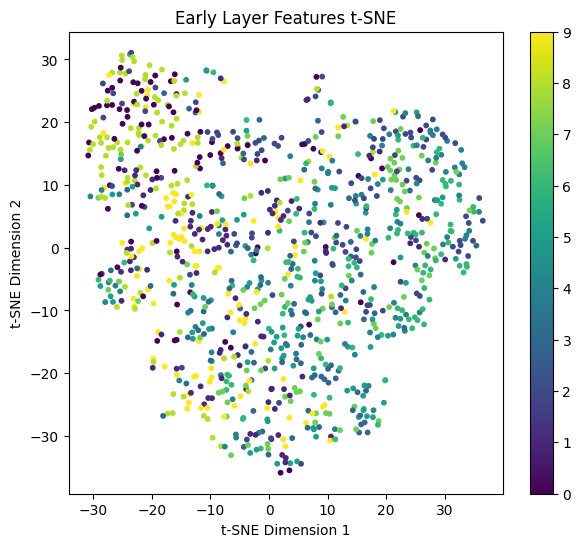

In [23]:
labels_np = all_labels.numpy()

plt.figure(figsize=(7, 6))

scatter = plt.scatter(early_2d[:, 0], early_2d[:, 1], c=labels_np, s=10)

plt.title("Early Layer Features t-SNE")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.colorbar(scatter)

plt.show()

**Middle Layer Plot:**

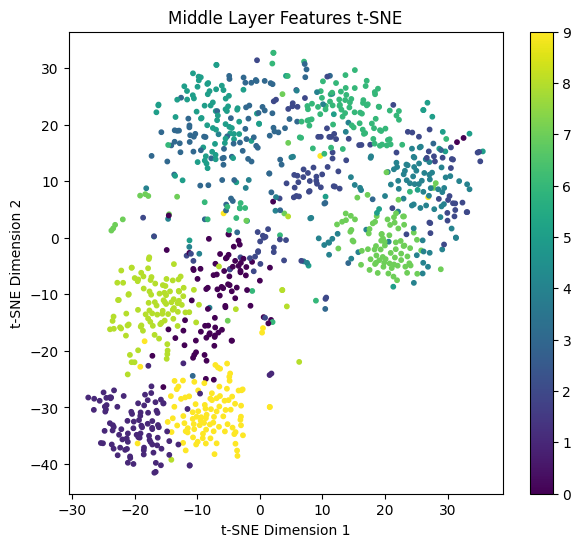

In [24]:
plt.figure(figsize=(7, 6))

scatter = plt.scatter(middle_2d[:, 0], middle_2d[:, 1], c=labels_np, s=10)

plt.title("Middle Layer Features t-SNE")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.colorbar(scatter)

plt.show()

**Later Layer Plot:**

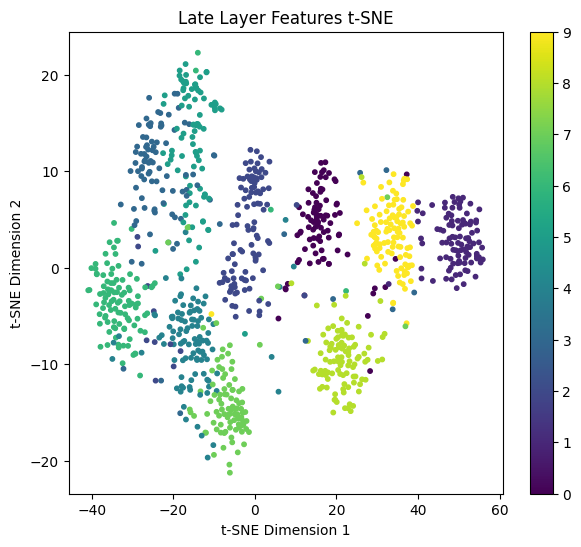

In [25]:
plt.figure(figsize=(7, 6))

scatter = plt.scatter(late_2d[:, 0],late_2d[:, 1], c=labels_np, s=10)

plt.title("Late Layer Features t-SNE")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.colorbar(scatter)

plt.show()